# Donghang Zou's UChicago ADS Code Sample

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship

### 1. Motivation and data

This sample is an excerpt from my Global AI internship project; the full code and analysis are available at the GitHub link above. Chronic disease burden is uneven across U.S. counties, so understanding its social correlates can help target public health resources. The project combines CDC PLACES 2021 to 2025 and SVI 2020/2022 into a panel, compares diabetes and hypertension correlates, and maps K-means profiles; this excerpt uses PLACES 2025 and SVI 2022. Among 16 tested factors, food, housing and transportation insecurity correlate most strongly with diabetes (r = 0.937, 0.921, 0.914).

### 2. Setup and loading the data

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ROOT = Path.cwd().parent if Path.cwd().name == 'code_sample' else Path.cwd()
RAW, OUT = ROOT / 'data/raw', ROOT / 'code_sample'
outcomes = ['DIABETES', 'BPHIGH']
factor_labels = {'LPA': 'Inactivity', 'OBESITY': 'Obesity', 'CSMOKING': 'Smoking', 'ACCESS2': 'Uninsured',
    'DEPRESSION': 'Depression', 'SLEEP': 'Short sleep', 'BINGE': 'Binge drinking',
    'RPL_THEMES': 'Overall SVI', 'RPL_THEME1': 'SVI: socioeconomic', 'RPL_THEME2': 'SVI: household',
    'RPL_THEME3': 'SVI: minority', 'RPL_THEME4': 'SVI: housing/transport', 'FOODINSECU': 'Food insecurity',
    'HOUSINSECU': 'Housing insecurity', 'LACKTRPT': 'Transport barriers', 'LONELINESS': 'Loneliness'}
factors = list(factor_labels)
svi_cols = [factor for factor in factors if factor.startswith('RPL')]
# String identifiers preserve leading zeros.
places = pd.read_csv(RAW / 'places_county_2025.csv', low_memory=False,
    dtype={'locationid': 'string', 'year': 'int16', 'data_value': 'float64'})
svi = pd.read_csv(RAW / 'svi_county_2022.csv', dtype={'FIPS': 'string'}, usecols=['FIPS', *svi_cols])
print(f'FIPS: {places.locationid.dtype}/{svi.FIPS.dtype}; prevalence: {places.data_value.dtype}')

Matplotlib is building the font cache; this may take a moment.


FIPS: string/string; prevalence: float64


### 3. Building the county snapshot



In [3]:
def prepare_county_snapshot(places, svi, outcomes):
    health = places.query("stateabbr != 'US' and data_value_type == 'Age-adjusted prevalence'").copy()
    health['FIPS'] = health.locationid.str.zfill(5)
    health = health.sort_values('year').drop_duplicates(['FIPS', 'measureid'], keep='last')
    wide = health.pivot(index='FIPS', columns='measureid', values='data_value')
    # Treat -999 as missing.
    svi = svi.assign(FIPS=svi.FIPS.str.zfill(5)).replace(-999, np.nan).set_index('FIPS')
    # Validation raises an error for duplicate county identifiers.
    return wide.join(svi, validate='one_to_one').dropna(subset=[*outcomes, 'RPL_THEMES'])
counties = prepare_county_snapshot(places, svi, outcomes)

### 4. Measuring associations

Pairwise Pearson r uses available observations; the common sample fixes the same counties for all 16 factors.

In [4]:
def compare_correlations(data, outcome, factors, sample_policy='pairwise'):
    values = data[[outcome, *factors]].dropna(subset=[outcome])
    if sample_policy == 'common':
        values = values.dropna()
    return pd.DataFrame({'r': values[factors].corrwith(values[outcome]), 'n': values[factors].count()})
results = {outcome: compare_correlations(counties, outcome, factors) for outcome in outcomes}
correlations = pd.DataFrame({outcome: result.r for outcome, result in results.items()})
shown = ['FOODINSECU', 'HOUSINSECU', 'LACKTRPT', 'LPA']
common = compare_correlations(counties, 'DIABETES', factors, 'common')
comparison = results['DIABETES'].join(common, lsuffix='_pair', rsuffix='_common').loc[shown]
print(comparison.round(3).rename_axis(None))

            r_pair  n_pair  r_common  n_common
FOODINSECU   0.937    2299     0.937      2299
HOUSINSECU   0.921    2299     0.921      2299
LACKTRPT     0.914    2299     0.914      2299
LPA          0.873    2956     0.850      2299


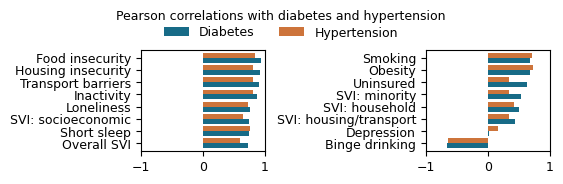

In [5]:
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 9, 'figure.titlesize': 9})
def plot_correlations(correlations, factor_labels):
    ranked = correlations.sort_values('DIABETES', ascending=False).rename(index=factor_labels)
    fig, axes = plt.subplots(1, 2, figsize=(5.6, 1.75))
    for ax, start in zip(axes, [0, 8]):
        ranked.iloc[start:start + 8].iloc[::-1].plot.barh(ax=ax, width=.8,
            color=['#176b87', '#cd743b'], legend=False)
        ax.set(xlim=(-1, 1), xticks=[-1, 0, 1], xlabel='', ylabel='')
    fig.suptitle('Pearson correlations with diabetes and hypertension')
    fig.legend(axes[0].containers, ['Diabetes', 'Hypertension'], loc='upper center',
        bbox_to_anchor=(.5, .95), ncol=2, frameon=False)
    fig.subplots_adjust(left=.25, right=.98, bottom=.17, top=.75, wspace=1.3)
    return fig
figure = plot_correlations(correlations, factor_labels)
figure.savefig(OUT / 'figures/fig_correlations.png', dpi=240)
plt.show()

### 5. Grouping and mapping counties

Standardize before K-means so units do not drive distance. Means are unweighted (age-adjusted prevalence %, SVI percentile rank 0 to 1).

In [6]:
strength = correlations.abs().mean(axis=1).sort_values(ascending=False)
features = outcomes + strength[strength >= .40].index.tolist()
complete = counties.dropna(subset=features).copy()
scaled = StandardScaler().fit_transform(complete[features])
model = KMeans(n_clusters=4, random_state=42, n_init=10).fit(scaled)
anchors = [features.index(factor) for factor in [*outcomes, 'RPL_THEMES']]
# Order tiers by mean standardized diabetes, hypertension, and SVI.
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ['Low', 'Moderate', 'High', 'Highest']
labels = pd.Series(model.labels_, index=complete.index).map(dict(zip(order, tiers)))
complete['tier'] = pd.Categorical(labels, categories=tiers, ordered=True)
summary = complete.groupby('tier', observed=True).agg(counties=('DIABETES', 'size'),
    diabetes=('DIABETES', 'mean'), hypertension=('BPHIGH', 'mean'), SVI=('RPL_THEMES', 'mean'))
print(f'{len(complete):,} clustered counties; silhouette = {silhouette_score(scaled, model.labels_):.3f}')
print(summary.round(3).rename_axis(None).to_string())

2,299 clustered counties; silhouette = 0.203
          counties  diabetes  hypertension    SVI
Low            765     9.090        29.758  0.190
Moderate       788    10.765        33.306  0.456
High           508    12.555        36.755  0.754
Highest        238    15.786        42.943  0.895


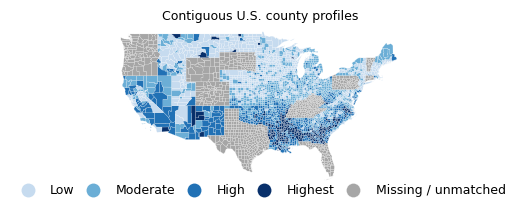

In [7]:
def plot_county_profiles(complete):
    geo = gpd.read_file(ROOT / 'data/processed/us_counties.geojson')
    geo = geo.set_index(geo.STATE + geo.COUNTY)
    geo = geo.loc[~geo.STATE.isin(['02', '15', '72'])].join(complete.tier, validate='one_to_one')
    palette = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']
    fig, ax = plt.subplots(figsize=(5.6, 2.1))
    legend = dict(loc='lower center', bbox_to_anchor=(.5, -.16), ncol=5, frameon=False, columnspacing=.5)
    geo.plot(column='tier', ax=ax, cmap=ListedColormap(palette), edgecolor='white', linewidth=.12,
        legend=True, legend_kwds=legend, missing_kwds={'color': '#a6a6a6', 'label': 'Missing / unmatched'})
    ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25, title='Contiguous U.S. county profiles')
    ax.axis('off')
    fig.subplots_adjust(left=.02, right=.98, top=.9, bottom=.16)
    return fig
figure = plot_county_profiles(complete)
figure.savefig(OUT / 'figures/fig_risk_tier_map.png', dpi=240)
plt.show()

Grey: nine states lack social-needs data; KY/PA lack disease estimates; some boundaries are unmatched. Nine CT planning regions lack geometry.

### 6. Findings and limits

When all factors use the same 2,299 counties, food, housing, and transportation insecurity remain the strongest correlates, while the link with physical inactivity weakens, showing that sample choice affects the size of an association even when the ranking holds. Higher-burden profiles cluster in the Deep South. These patterns are descriptive, not causal: measurement years differ, profiles overlap, and shared inputs to the PLACES models may inflate correlations.